In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [147]:
df = pd.read_csv("synthetic_customer_churn_100k.csv")

### ALL DATA

In [148]:
df.head(20)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No
5,6,25,Female,29,111.55,Month-to-month,Credit card,3167.13,Yes
6,7,78,Female,20,63.23,One year,Electronic check,1307.22,No
7,8,38,Male,11,96.63,Month-to-month,Bank transfer,1093.32,Yes
8,9,56,Male,43,74.06,Month-to-month,Mailed check,3230.58,Yes
9,10,75,Other,62,109.39,One year,Electronic check,6799.64,No


In [149]:
df.tail(20)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
99980,99981,31,Male,13,82.69,Two year,Credit card,1036.68,No
99981,99982,56,Male,29,99.06,Two year,Electronic check,2928.68,No
99982,99983,35,Male,44,79.51,Month-to-month,Mailed check,3567.54,Yes
99983,99984,55,Female,50,12.78,Month-to-month,Mailed check,553.31,Yes
99984,99985,39,Female,63,101.63,Month-to-month,Electronic check,6395.25,No
99985,99986,55,Male,26,120.79,Month-to-month,Mailed check,3155.72,No
99986,99987,72,Female,24,79.43,Month-to-month,Mailed check,1935.36,No
99987,99988,28,Female,42,118.97,Two year,Electronic check,4964.07,No
99988,99989,20,Male,23,109.49,One year,Electronic check,2445.74,No
99989,99990,78,Female,50,94.66,Month-to-month,Electronic check,4765.99,Yes


In [150]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  str    
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  str    
 6   PaymentMethod   100000 non-null  str    
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  str    
dtypes: float64(2), int64(3), str(4)
memory usage: 6.9 MB


In [151]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,49.027240,36.527090,79.974933,2926.140256
std,28867.657797,18.177862,20.789552,40.491961,2388.163672
min,1.000000,18.000000,1.000000,10.000000,-118.430000
25%,25000.750000,33.000000,18.000000,44.720000,963.667500
50%,50000.500000,49.000000,37.000000,80.000000,2268.060000
75%,75000.250000,65.000000,54.000000,115.050000,4394.327500
max,100000.000000,80.000000,72.000000,150.000000,10831.460000


In [152]:
df.isnull().sum()

CustomerID        0
Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64

In [153]:
df.duplicated().sum()

np.int64(0)

In [154]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges', 'Contract',
       'PaymentMethod', 'TotalCharges', 'Churn'],
      dtype='str')

In [155]:
df.shape

(100000, 9)

### DATA CLEANING

### Standarisasi Nama Kolom

In [156]:
df.columns = df.columns.str.lower() ### mengubah nama kolom menjadi huruf kecil semuanya

In [157]:
df.columns

Index(['customerid', 'age', 'gender', 'tenure', 'monthlycharges', 'contract',
       'paymentmethod', 'totalcharges', 'churn'],
      dtype='str')

In [158]:
df = df.rename(columns={
    "customerid" : "customer_id",
    "monthlycharges" : "monthly_charges",
    "totalcharges" : "total_charges",
    "paymentmethod" : "payment_method",

})

In [159]:
df.columns

Index(['customer_id', 'age', 'gender', 'tenure', 'monthly_charges', 'contract',
       'payment_method', 'total_charges', 'churn'],
      dtype='str')

### Perbaikan Tipe Data

In [160]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   customer_id      100000 non-null  int64  
 1   age              100000 non-null  int64  
 2   gender           100000 non-null  str    
 3   tenure           100000 non-null  int64  
 4   monthly_charges  100000 non-null  float64
 5   contract         100000 non-null  str    
 6   payment_method   100000 non-null  str    
 7   total_charges    100000 non-null  float64
 8   churn            100000 non-null  str    
dtypes: float64(2), int64(3), str(4)
memory usage: 6.9 MB


### Missing Value

In [161]:
df.isnull().sum()

customer_id        0
age                0
gender             0
tenure             0
monthly_charges    0
contract           0
payment_method     0
total_charges      0
churn              0
dtype: int64

In [162]:
(df["total_charges"] == " ").sum()

np.int64(0)

In [163]:
(df["customer_id"] == " ").sum()

np.int64(0)

In [164]:
(df["age"] == " ").sum()

np.int64(0)

In [165]:
(df["gender"] == " ").sum()

np.int64(0)

In [166]:
(df["tenure"] == " ").sum()

np.int64(0)

In [167]:
(df["monthly_charges"] == " ").sum()

np.int64(0)

In [168]:
(df["contract"] == " ").sum()

np.int64(0)

In [169]:
(df["payment_method"] == " ").sum()

np.int64(0)

In [170]:
(df["churn"] == " ").sum()

np.int64(0)

### EXPLORATY DATA ANALYST ###

### Churn Distribution

In [171]:
df["churn"].value_counts(normalize=True) * 100

churn
No     66.856
Yes    33.144
Name: proportion, dtype: float64

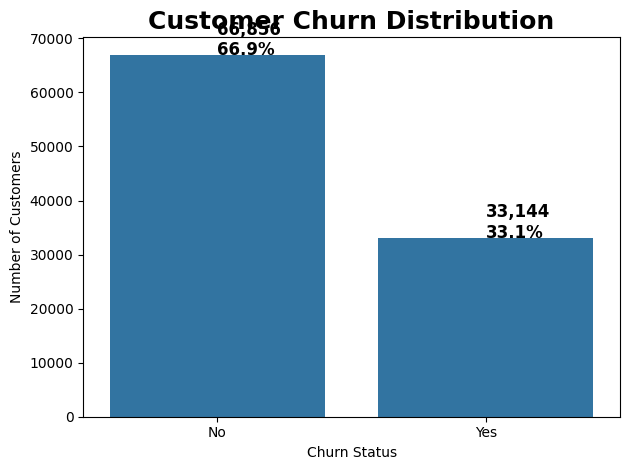

In [172]:
plt.Figure(figsize=(10,6))

ax = sns.countplot(
    data=df,
    x="churn"

)

total = len(df)

for p in ax.patches:
     count = p.get_height()
     percentage = count / total * 100
     
     ax.annotate(
         f"{count:,.0f}\n{percentage:.1f}%",
         (p.get_x() + p.get_width()/2, count),
         fontsize=12,
         fontweight="bold"
       
     )

plt.title(
    "Customer Churn Distribution",
    fontsize=18,
    fontweight="bold"
)     

plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Contract Type vs Churn

In [173]:
contract_churn = pd.crosstab(
    df["contract"],
    df["churn"],
    normalize="index"
) * 100

In [174]:
contract_churn

churn,No,Yes
contract,,
Month-to-month,53.442593,46.557407
One year,83.250861,16.749139
Two year,83.121469,16.878531


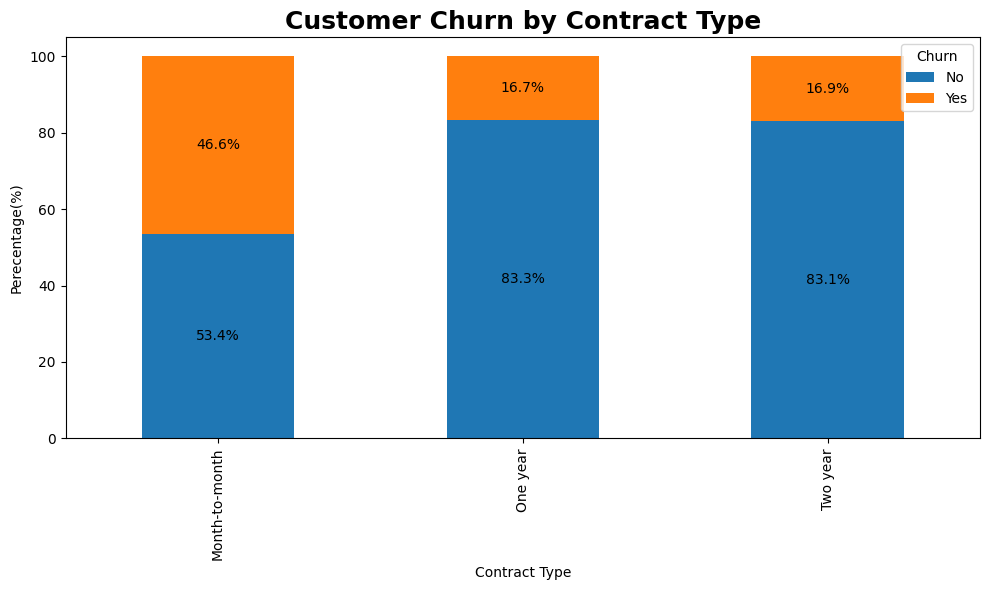

In [175]:
contract_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title(
    "Customer Churn by Contract Type",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Contract Type")
plt.ylabel("Perecentage(%)")

for container in plt.gca().containers:
    plt.bar_label(
        container,
        fmt="%.1f%%",
        label_type="center"
    )
    
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

### Insight

1. Pelanggan dengan kontrak month - to - month lebih beresiko churn
2. Pelanggan dengan kontrak 1 tahun dan 2 tahun lebih loyal

Pelanggan dengan kontrak month - to - month memiliki tingkat churn tertinggi dibandingkan pelanggan kontrak tahunan. Hal ini menunjukkan bahwa semakin pendek komitmen kontrak pelanggan, semakin besar kemungkinan mereka berpindah ke kompetitor.


### Business Recomendation

1. Berikan diskon migrasi ke kontrak tahunan
2. Program loyalitas untuk pelanggan month-to-month

### Payment Method vs Churn

In [176]:
payment_churn = pd.crosstab(
    df["payment_method"],
    df["churn"],
    normalize="index"
) * 100

payment_churn

churn,No,Yes
payment_method,,
Bank transfer,66.995719,33.004281
Credit card,67.207468,32.792532
Electronic check,66.711567,33.288433
Mailed check,66.666667,33.333333


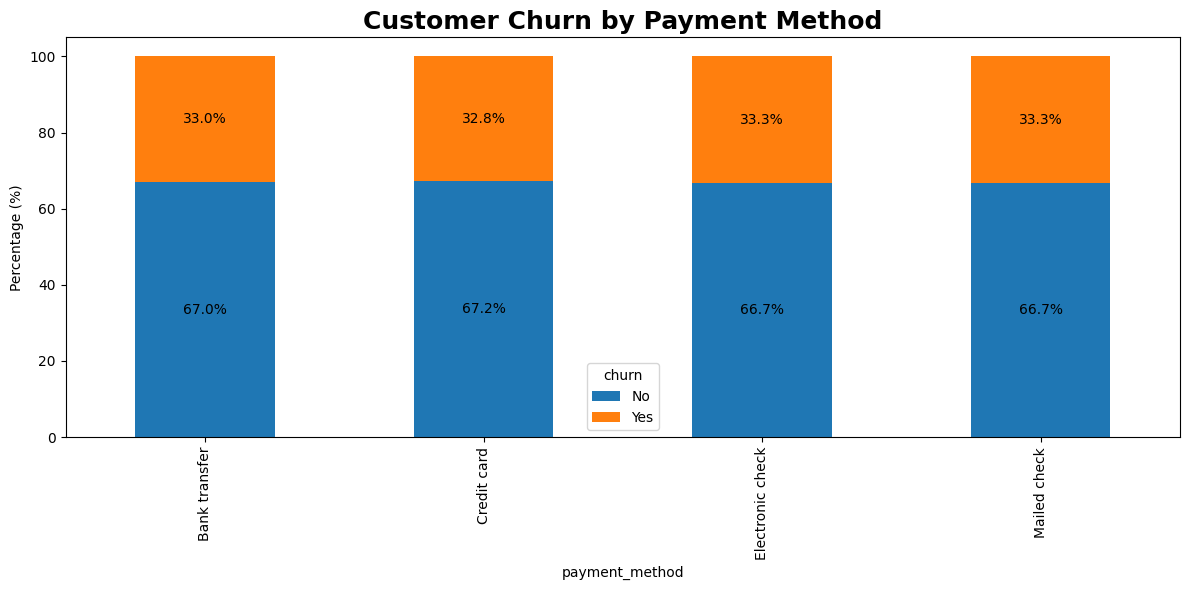

In [177]:
payment_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title(
    "Customer Churn by Payment Method",
    fontsize=18,
    fontweight="bold"
)

plt.ylabel("Percentage (%)")

for container in plt.gca().containers:
    plt.bar_label(
        container,
        fmt="%.1f%%",
        label_type="center"
    )
    
plt.tight_layout()
plt.show()

### Insight

1. Methode pembayaran tidak memiliki perbedaan yang signifikan
2. Artinya payment method tidak memiliki pengaruh untuk berhenti berlangganan

tidak terdapat perbedaan signifikan tingkat churn antara setiap metode pembayaran. hal ini menunjukkan bahwa metode pembayaran bukanlah faktor utama pelanggan untuk berhenti berlangganan


### Gender vs Churn

In [178]:
gender_churn = pd.crosstab(
    df["gender"],
    df["churn"],
    normalize="index"
) * 100

gender_churn

churn,No,Yes
gender,,
Female,67.152271,32.847729
Male,66.614351,33.385649
Other,66.161233,33.838767


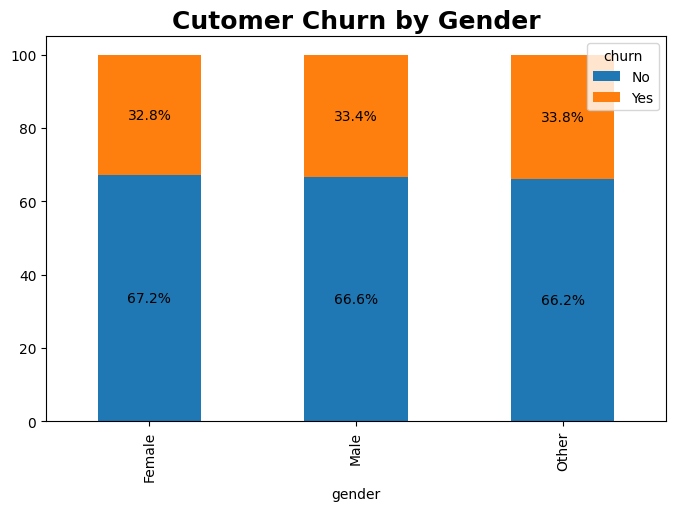

In [179]:
gender_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title(
    "Cutomer Churn by Gender",
    fontsize=18,
    fontweight="bold"
)

for container in plt.gca().containers:
    plt.bar_label(
        container,
        fmt="%.1f%%",
        label_type="center"
)

plt.show()

### Insight

1. Setiap Gender memiliki persentase yang sama dalam hal pindahnya pelanggan
2. Artinya gender tidak memiliki pengaruh yang sangat significant dalam hal ini.

Tidak terdapat perbedaan signifikan tingkat churn antara pelanggan pria dan wanita. hal ini menunjukkan bahwa gender bukan merupakan faktor utama yang mempengaruhi keputusan pelanggan untuk berhenti berlangganan

### Age vs Churn

In [180]:
df.groupby("churn")["age"].describe()


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
No,66856.0,49.102429,18.189906,18.0,33.0,49.0,65.0,80.0
Yes,33144.0,48.875573,18.152871,18.0,33.0,49.0,65.0,80.0


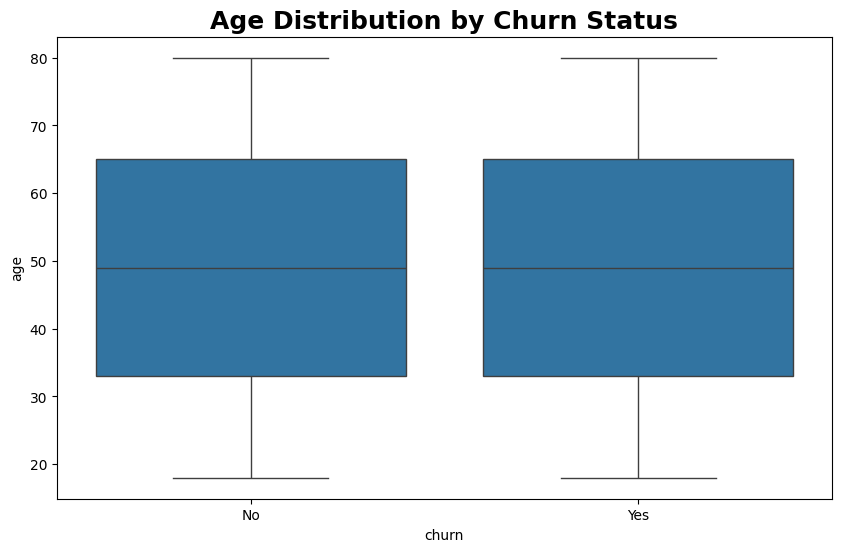

In [181]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="churn",
    y="age",
    data=df
)

plt.title(
    "Age Distribution by Churn Status",
    fontsize=18,
    fontweight='bold'
)

plt.show()

### Insight

1. Umur tidak memiliki perbedaan yang signifikan satu sama lain
2. Artinya umur bukan faktor utama customer dalam berhentinya berlangganan

tidak terdapat perbedaan signifikan tingat churn dalam umur. hal ini menunjukkan umur berapapun itu tidak mempengaruhi keputusan pelanggan untuk berhenti berlangganan

### Tenor vs Churn

In [182]:
df.groupby("churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
No,66856.0,39.321796,19.424077,1.0,23.0,40.0,56.0,72.0
Yes,33144.0,30.889784,22.258649,1.0,9.0,28.0,51.0,72.0


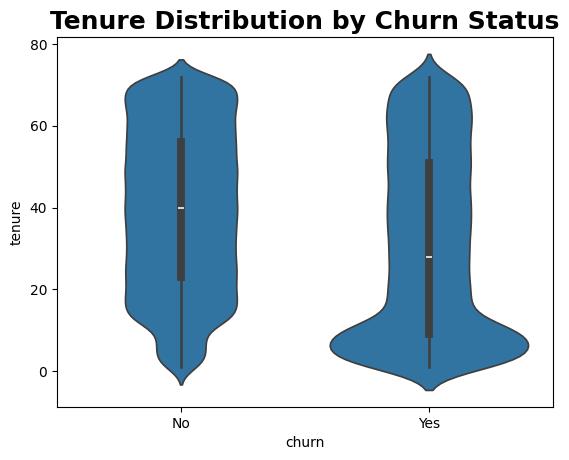

In [183]:
plt.Figure(figsize=(10,6))

sns.violinplot(
    x="churn",
    y="tenure",
    data=df
)

plt.title(
    "Tenure Distribution by Churn Status",
    fontsize=18,
    fontweight="bold"
)

plt.show()

### Insight

1. Pelanggan dengan tenor waktu 24 - 58 bulan tidak beresiko berhenti berlanggan
2. Pelanggan dengan tenor waktu 9 - 50 bulan lebih beresiko  berhenti berlangganan

Pelanggan yang beresiko berhenti berlangganan cenderung memiliki masa berlangganan yang lebih panjang

In [184]:
df.groupby("churn")["monthly_charges"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
No,66856.0,72.845838,38.653979,10.0,40.0975,70.34,100.7500,150.0
Yes,33144.0,94.355298,40.295908,10.0,61.5200,105.84,127.8125,150.0


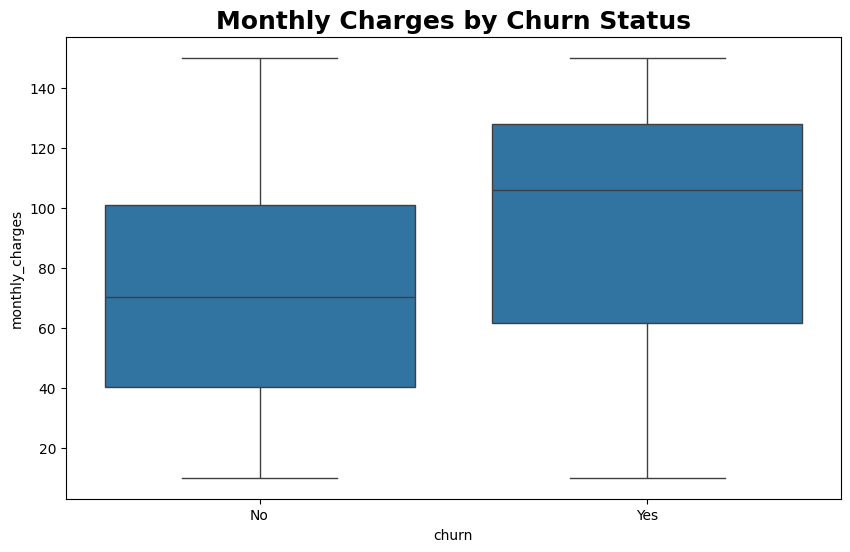

In [185]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="churn",
    y="monthly_charges",
    data=df
)

plt.title(
    "Monthly Charges by Churn Status",
    fontsize=18,
    fontweight="bold"
)

plt.show()

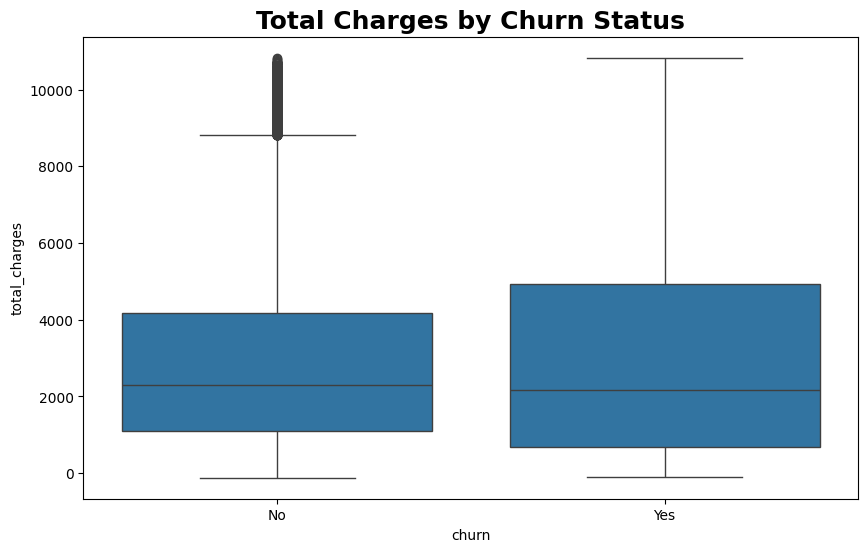

In [186]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="churn",
    y="total_charges",
    data=df
)

plt.title(
    "Total Charges by Churn Status",
    fontsize=18,
    fontweight="bold"
)
plt.show()

### Correlation Heatmap

In [187]:
numeric_cols = [
    'age',
    "tenure",
    "monthly_charges",
    "total_charges",
]

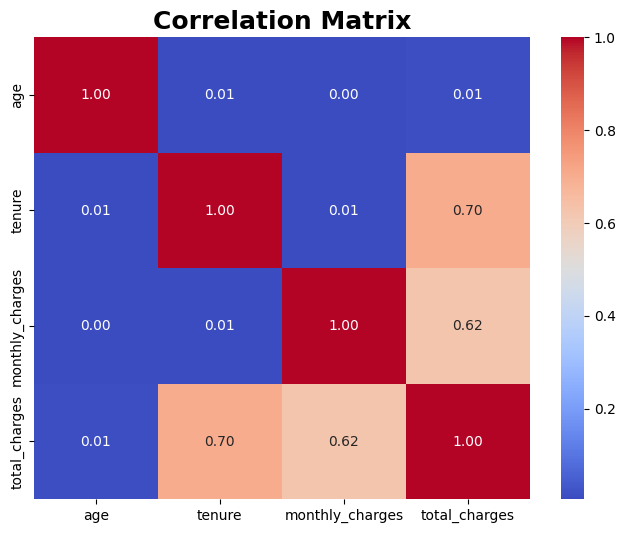

In [188]:
plt.figure(figsize=(8,6))

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Matrix",
    fontsize=18,
    fontweight="bold"
)

plt.show()

### Top Risk Segment

In [189]:
pd.crosstab(
    [df["contract"],
     df["payment_method"]],
    df["churn"],
    normalize="index"
) * 100

churn                                   No        Yes
contract       payment_method                        
Month-to-month Bank transfer     53.668918  46.331082
               Credit card       53.544096  46.455904
               Electronic check  53.437014  46.562986
               Mailed check      53.193180  46.806820
One year       Bank transfer     83.777383  16.222617
               Credit card       83.493621  16.506379
               Electronic check  82.944939  17.055061
               Mailed check      83.057526  16.942474
Two year       Bank transfer     81.813615  18.186385
               Credit card       84.120172  15.879828
               Electronic check  83.352804  16.647196
               Mailed check      83.055224  16.944776

### Age Segmentation

In [190]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 45, 55, 100],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "55+"
    ]
)

In [191]:
age_churn = pd.crosstab(
    df["age_group"],
    df["churn"],
    normalize="index"
) * 100

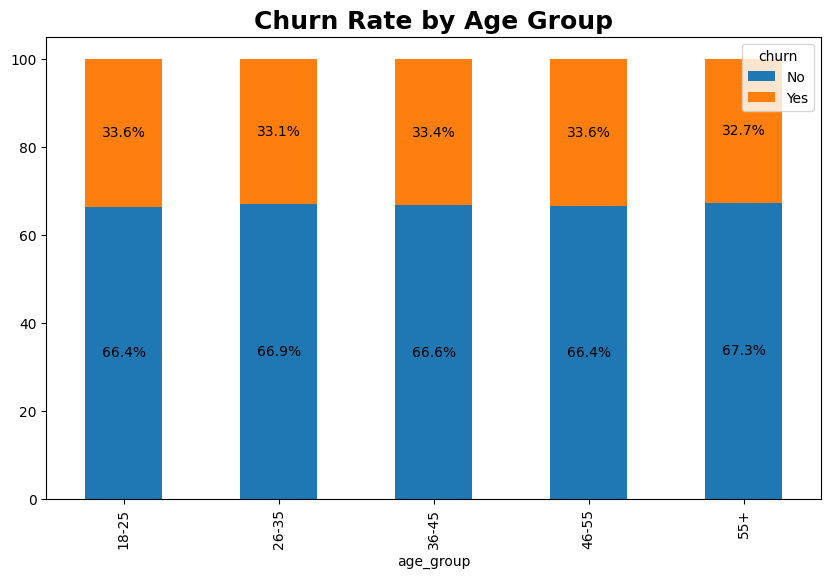

In [192]:
ax = age_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title(
    "Churn Rate by Age Group",
    fontsize=18,
    fontweight="bold"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="center"
    )
    
plt.show()

### Tenure Segmentation

In [193]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49 - 72 Months",
    ]
)

In [194]:
tenure_churn = pd.crosstab(
    df["tenure_group"],
    df["churn"],
    normalize="index"
) * 100

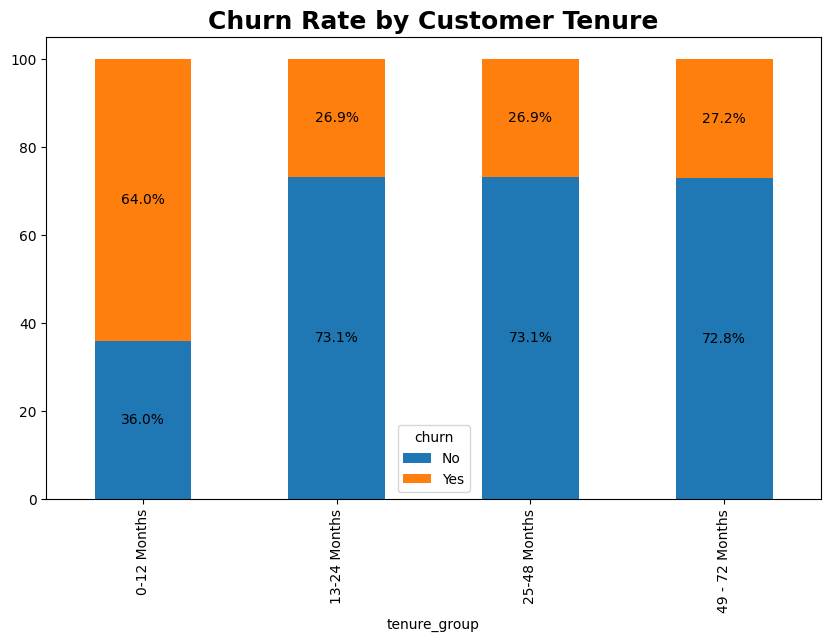

In [195]:
ax = tenure_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title(
    "Churn Rate by Customer Tenure",
    fontsize=18,
    fontweight="bold"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="center"
    )
    
plt.show()

### Monthly Charges Segmentation

In [196]:
df["charge_group"] = pd.qcut(
    df["monthly_charges"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [197]:
charge_churn = pd.crosstab(
    df["charge_group"],
    df["churn"],
    normalize="index"
) * 100

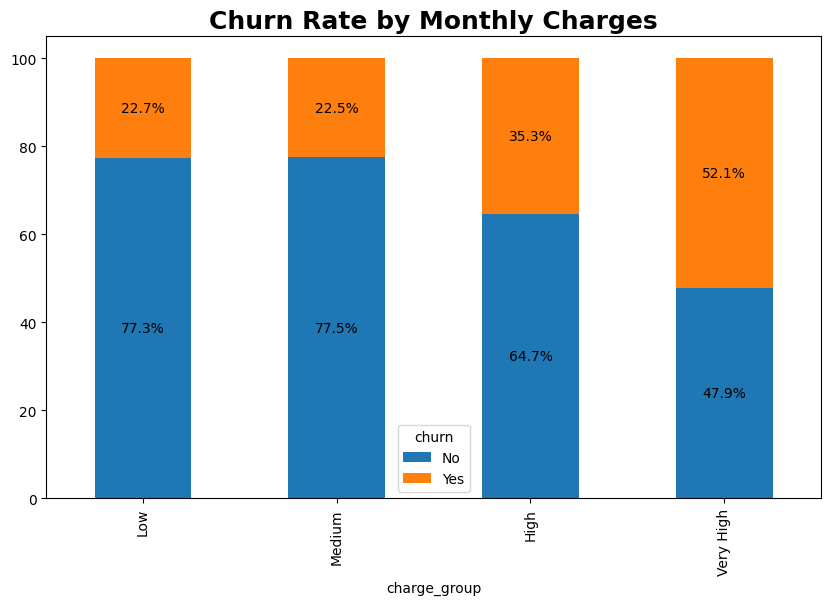

In [198]:
ax = charge_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title(
    "Churn Rate by Monthly Charges",
    fontsize=18,
    fontweight="bold"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="center"
    )

plt.show()

### Risk Profile

In [199]:
risk_profile = pd.crosstab(
    [
        df["contract"],
        df["tenure_group"]
    ],
    df["churn"],
    normalize="index"
) * 100

risk_profile.sort_values(
    by="Yes",
    ascending=False
).head(10)

churn                                 No        Yes
contract       tenure_group                        
Month-to-month 0-12 Months     22.463927  77.536073
Two year       0-12 Months     52.402539  47.597461
One year       0-12 Months     52.577566  47.422434
Month-to-month 49 - 72 Months  59.226858  40.773142
               13-24 Months    59.548707  40.451293
               25-48 Months    60.082640  39.917360
Two year       25-48 Months    88.986580  11.013420
               13-24 Months    88.988095  11.011905
One year       49 - 72 Months  89.053781  10.946219
               25-48 Months    89.403974  10.596026

### Executive Summary Dashboard

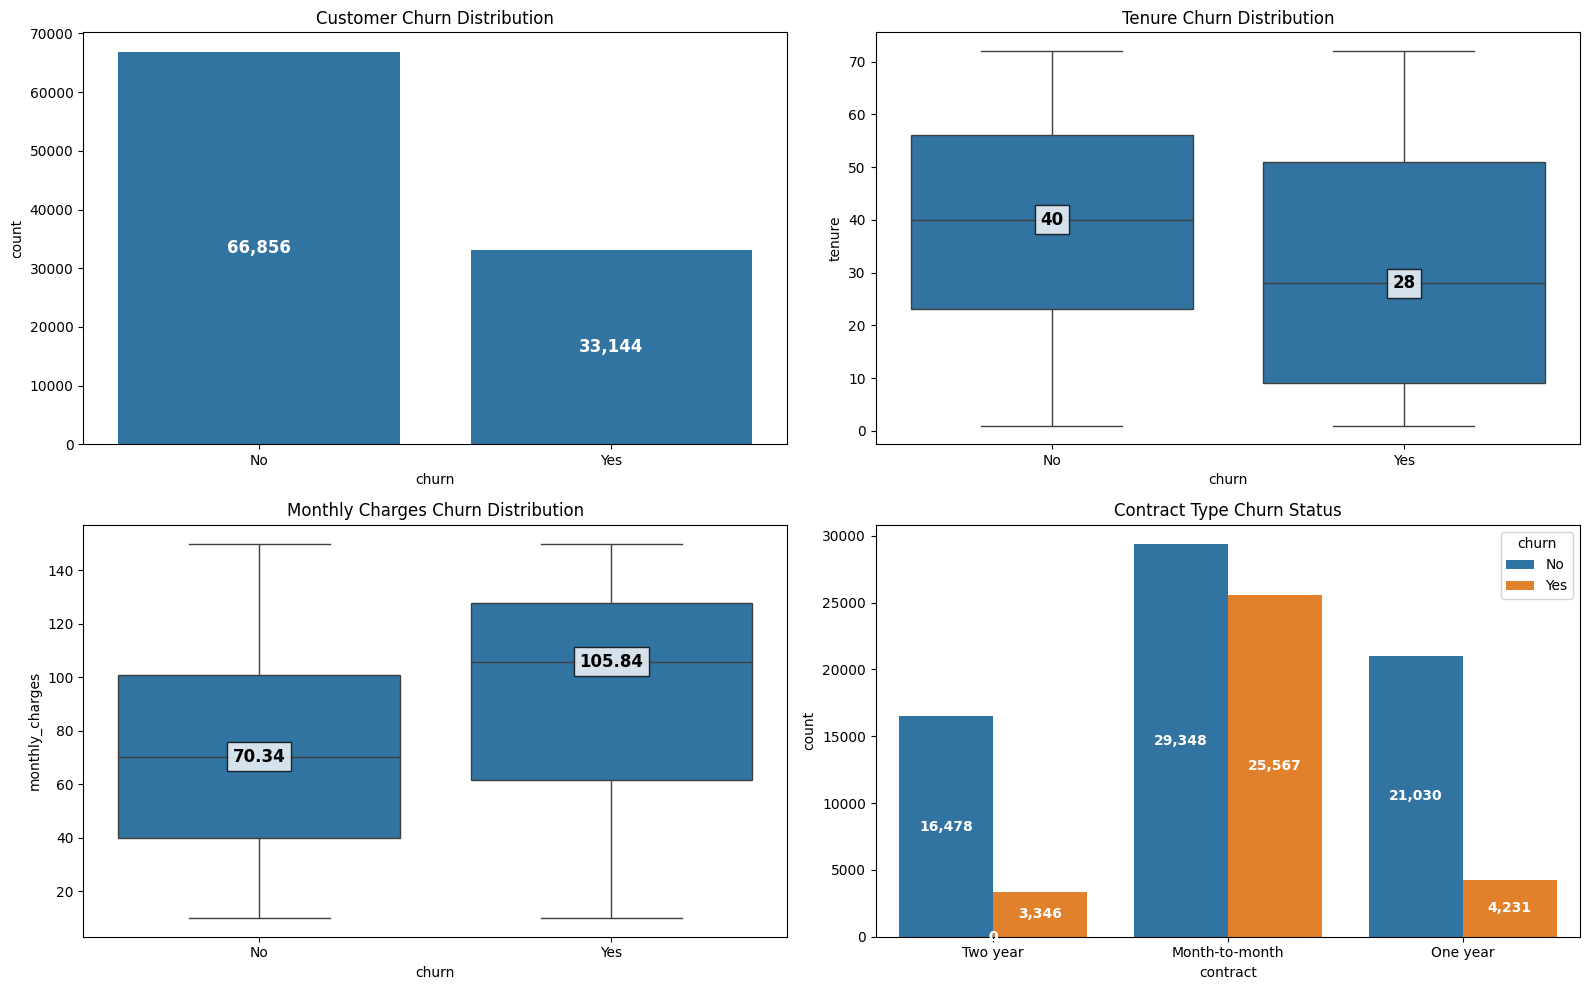

In [200]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(16,10)
)

ax1 =sns.countplot(
    x="churn",
    data=df,
    ax=axes[0,0]
)

for p in ax1.patches:
    count = int(p.get_height())
    
    ax1.annotate(
        f"{count:,}",
        (p.get_x() + p.get_width()/2, p.get_height()/2),
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color="white"
    )

ax1.set_title("Customer Churn Distribution")

ax2 =sns.boxplot(
    x="churn",
    y="tenure",
    data=df,
    ax=axes[0,1]
)

tenure_median = df.groupby("churn")["tenure"].median()

for i, value in enumerate(tenure_median):
    
    ax2.text(
        i,
        value,
        f"{value:.0f}",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.8)
    )

ax2.set_title("Tenure Churn Distribution")

ax3 =sns.boxplot(
    x="churn",
    y="monthly_charges",
    data=df,
    ax=axes[1,0]
)

charges_median = df.groupby("churn")["monthly_charges"].median()

for i, value in enumerate(charges_median):
    ax3.text(
        i,
        value,
        f"{value:.2f}",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.8)
    )

ax3.set_title("Monthly Charges Churn Distribution")


ax4 =sns.countplot(
    x="contract",
    hue="churn",
    data=df,
    ax=axes[1,1]
)

for p in ax4.patches:
    count = int(p.get_height())
    
    ax4.annotate(
        f"{count:,}",
        (p.get_x() + p.get_width()/2, p.get_height()/2),
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="white"
    )

ax4.set_title("Contract Type Churn Status")

plt.tight_layout()
plt.show()

### FEATURE ENGINEERING ###

Hapus Kolom yg tidak memiliki nilai deskriptif

In [201]:
df = df.drop(columns=["customer_id"])

Periksa kembali target
- jika masih berupa "yes" atau "no", ubah menjadi 0 atau 1

In [202]:
df["churn"].value_counts()

churn
No     66856
Yes    33144
Name: count, dtype: int64

In [203]:
df["churn"] = df["churn"].map({
    "No" : 0,
    "Yes" : 1
})

In [204]:
df["churn"].value_counts()

churn
0    66856
1    33144
Name: count, dtype: int64

kelompokkan tenure

In [205]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins = [0,12,24,48,72],
    labels = [
        "0-12",
        "13-24",
        "25-48",
        "49-72"
    ] 
)

kelompokkan monthly charges

In [206]:
df["charge_group"] = pd.qcut(
    df["monthly_charges"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

periksa kembali multikolinearitas

In [207]:
df.corr(numeric_only=True)

,age,tenure,monthly_charges,total_charges,churn
age,1.000000,0.007915,0.004835,0.008958,-0.005875
tenure,0.007915,1.000000,0.005976,0.700959,-0.190924
monthly_charges,0.004835,0.005976,1.000000,0.623864,0.250055
total_charges,0.008958,0.700959,0.623864,1.000000,0.023860
churn,-0.005875,-0.190924,0.250055,0.023860,1.000000


In [208]:
df.columns.tolist()

['age',
 'gender',
 'tenure',
 'monthly_charges',
 'contract',
 'payment_method',
 'total_charges',
 'churn',
 'age_group',
 'tenure_group',
 'charge_group']

### ENCODING

In [209]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype   
---  ------           --------------   -----   
 0   age              100000 non-null  int64   
 1   gender           100000 non-null  str     
 2   tenure           100000 non-null  int64   
 3   monthly_charges  100000 non-null  float64 
 4   contract         100000 non-null  str     
 5   payment_method   100000 non-null  str     
 6   total_charges    100000 non-null  float64 
 7   churn            100000 non-null  int64   
 8   age_group        100000 non-null  category
 9   tenure_group     100000 non-null  category
 10  charge_group     100000 non-null  category
dtypes: category(3), float64(2), int64(3), str(3)
memory usage: 6.4 MB


Pisahkan Fitur dan Target

In [210]:
x = df.drop("churn", axis=1)
y = df["churn"]

In [211]:
x.select_dtypes(include=["object", "category"]).columns

/var/folders/mv/skvcdpf120n49ky9gxc1y9w00000gn/T/ipykernel_74272/2232479517.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  x.select_dtypes(include=["object", "category"]).columns


Index(['gender', 'contract', 'payment_method', 'age_group', 'tenure_group',
       'charge_group'],
      dtype='str')

One Hot Encoding

In [212]:
x_encoded = pd.get_dummies(
    x,
    columns=[
        "gender",
        "contract",
        "payment_method",
        "age_group",
        "tenure_group",
        "charge_group"
    ],
    drop_first=True
)

periksa hasil

In [213]:
x_encoded.head()

,age,tenure,monthly_charges,total_charges,gender_Male,gender_Other,contract_One year,contract_Two year,payment_method_Credit card,payment_method_Electronic check,...,age_group_26-35,age_group_36-45,age_group_46-55,age_group_55+,tenure_group_13-24,tenure_group_25-48,tenure_group_49-72,charge_group_Medium,charge_group_High,charge_group_Very High
0,56,68,147.58,10052.03,False,False,False,True,False,False,...,False,False,False,True,False,False,True,False,False,True
1,69,32,22.54,686.78,True,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
2,46,10,52.47,537.88,False,False,True,False,False,True,...,False,False,True,False,False,False,False,True,False,False
3,32,22,109.67,2390.04,True,False,False,False,False,False,...,True,False,False,False,True,False,False,False,True,False
4,60,54,130.98,7081.28,False,False,False,False,True,False,...,False,False,False,True,False,False,True,False,False,True


In [214]:
x_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   age                              100000 non-null  int64  
 1   tenure                           100000 non-null  int64  
 2   monthly_charges                  100000 non-null  float64
 3   total_charges                    100000 non-null  float64
 4   gender_Male                      100000 non-null  bool   
 5   gender_Other                     100000 non-null  bool   
 6   contract_One year                100000 non-null  bool   
 7   contract_Two year                100000 non-null  bool   
 8   payment_method_Credit card       100000 non-null  bool   
 9   payment_method_Electronic check  100000 non-null  bool   
 10  payment_method_Mailed check      100000 non-null  bool   
 11  age_group_26-35                  100000 non-null  bool   
 12  age_group_36-4

pastikan tidak ada kategorikal

In [215]:
x_encoded.select_dtypes(include=["object", "category"]).columns

Index([], dtype='str')

### TRAIN TEST SPLIT

pisahkan fitur dan target

In [216]:
x = df.drop("churn", axis=1)
y = df["churn"]

In [217]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

identifikasi kolom

In [218]:
categorical_features = [
    "gender",
    "contract",
    "payment_method",
    "age_group",
    "tenure_group",
    "charge_group",
]

In [219]:
numerical_features = [
    "age",
    "tenure",
    "monthly_charges",
    "total_charges"
]

buat preprocessor

In [220]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop="first",
                          handle_unknown="ignore"
                          ),
                            categorical_features
        ),
        (
            "num",
            StandardScaler(),
            numerical_features
        )
    ]
)

gabungkan dengan model

In [221]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

Pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        random_state=42,
        max_iter=1000
        ))
])

latih model

In [222]:
Pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

lakukan prediksi

### MODEL 1 LOGISTIC REGRESSION

In [223]:
y_pred = Pipeline.predict(x_test)

In [224]:
y_prob = Pipeline.predict_proba(x_test)[:,1]

import matric

In [225]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

hitung seluruh matriks

In [226]:
print("Accuracy :", accuracy_score(y_test, y_pred))

print("Precision :", precision_score(y_test, y_pred))

print("Recall :", recall_score(y_test, y_pred))

print("F1 Score :", f1_score(y_test, y_pred))

print("ROC AUC :", roc_auc_score(y_test, y_pred))

Accuracy : 0.7528
Precision : 0.6715536550600693
Recall : 0.4975109367928798
F1 Score : 0.57157712305026
ROC AUC : 0.6884383642157504


classificatoin report

In [227]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.88      0.83     13371
           1       0.67      0.50      0.57      6629

    accuracy                           0.75     20000
   macro avg       0.73      0.69      0.70     20000
weighted avg       0.74      0.75      0.74     20000



confussion matriks

In [228]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[11758  1613]
 [ 3331  3298]]


visualisasi confussion matriks

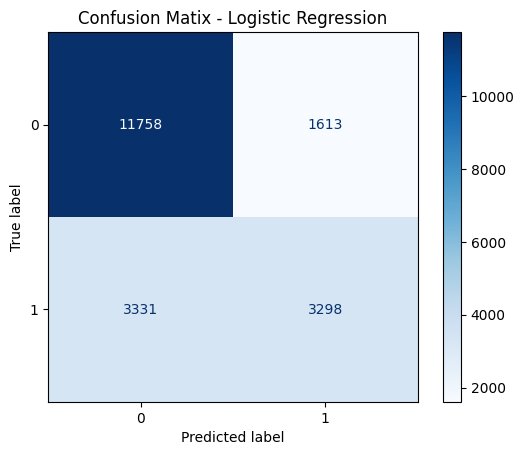

In [229]:
import matplotlib.pyplot as plt 
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matix - Logistic Regression")
plt.show()

### MODEL 2 DECISION TREE

buat pipeline

In [230]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

dt_pipline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]
)

In [231]:
print(dt_pipline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'contract',
                                                   'payment_method',
                                                   'age_group', 'tenure_group',
                                                   'charge_group']),
                                                 ('num', StandardScaler(),
                                                  ['age', 'tenure',
                                                   'monthly_charges',
                                                   'total_charges'])])),
                ('model', DecisionTreeClassifier(random_state=42))])


training

In [232]:
dt_pipline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

prediksi

In [233]:
y_pred_dt= dt_pipline.predict(x_test)

y_prob_dt = dt_pipline.predict_proba(x_test)[:, 1]

evaluasi

In [234]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.76      0.76      0.76     13371
           1       0.52      0.52      0.52      6629

    accuracy                           0.68     20000
   macro avg       0.64      0.64      0.64     20000
weighted avg       0.68      0.68      0.68     20000



In [235]:
print("Accuracy :", accuracy_score(y_test, y_pred_dt))

print("Precision :", precision_score(y_test, y_pred_dt))

print("Recall :", recall_score(y_test, y_pred_dt))

print("F1 Score :", f1_score(y_test, y_pred_dt))

print("ROC AUC :", roc_auc_score(y_test, y_prob_dt))


Accuracy : 0.67925
Precision : 0.5160179640718563
Recall : 0.5199879318147533
F1 Score : 0.5179953414982342
ROC AUC : 0.6390979970194849


confussion matrix

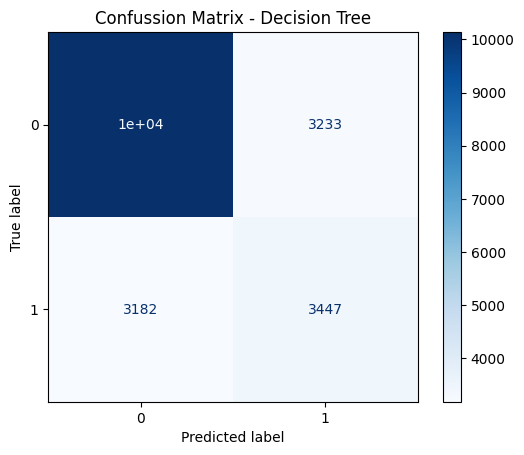

In [236]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    cmap="Blues"
)

plt.title("Confussion Matrix - Decision Tree")
plt.show()

### MODEL3 RANDOM FOREST

In [237]:
from sklearn.ensemble import RandomForestClassifier

buat pipeline

In [238]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            random_state=42,
            n_estimators=100
        ))
    ]
)

training model

In [239]:
rf_pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

prediksi

In [240]:
y_pred_rf = rf_pipeline.predict(x_test)

y_prob_rf = rf_pipeline.predict_proba(x_test)[:,1]

evaluasi model

In [241]:
print(classification_report(y_test, y_pred_rf))



              precision    recall  f1-score   support

           0       0.77      0.84      0.81     13371
           1       0.61      0.50      0.55      6629

    accuracy                           0.73     20000
   macro avg       0.69      0.67      0.68     20000
weighted avg       0.72      0.73      0.72     20000



In [242]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))

print("Precision :", precision_score(y_test, y_pred_rf))

print("Recall :", recall_score(y_test, y_pred_rf))

print("F1 Score :", f1_score(y_test, y_pred_rf))

print("ROC AUC :", roc_auc_score(y_test, y_prob_rf))


Accuracy : 0.72925
Precision : 0.6112536656891495
Recall : 0.5030924724694524
F1 Score : 0.5519238725693008
ROC AUC : 0.7866354539675982


confussion matrix

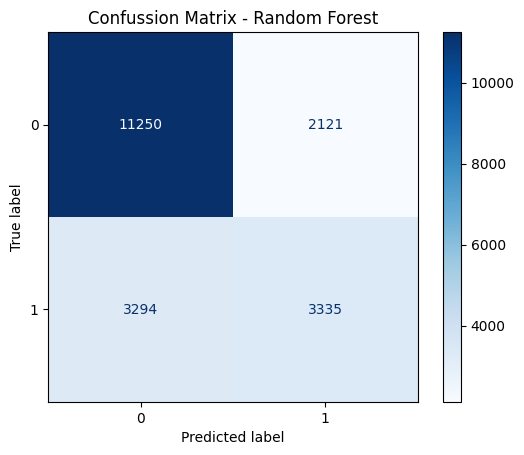

In [243]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Blues"
)

plt.title("Confussion Matrix - Random Forest")
plt.show()

### MODEL 4 XGBOOST

In [244]:
from xgboost import XGBClassifier

buat pipeline

In [245]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            random_state=42,
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            eval_metric="logloss"
        ))
    ]
)

training model

In [246]:
xgb_pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

prediksi

In [247]:
y_pred_xgb = xgb_pipeline.predict(x_test)

y_prob_xgb = xgb_pipeline.predict_proba(x_test)[:,1]

evaluasi

In [248]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
    
)

In [249]:
print(classification_report(y_test, y_pred_xgb))



              precision    recall  f1-score   support

           0       0.80      0.86      0.83     13371
           1       0.67      0.56      0.61      6629

    accuracy                           0.76     20000
   macro avg       0.73      0.71      0.72     20000
weighted avg       0.75      0.76      0.76     20000



In [250]:
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))

print("Precision :", precision_score(y_test, y_pred_xgb))

print("Recall :", recall_score(y_test, y_pred_xgb))

print("F1 Score :", f1_score(y_test, y_pred_xgb))

print("ROC AUC :", roc_auc_score(y_test, y_prob_xgb))


Accuracy : 0.76105
Precision : 0.665414878397711
Recall : 0.5613214662845075
F1 Score : 0.6089518042713362
ROC AUC : 0.8034937727981357


confussion matrix

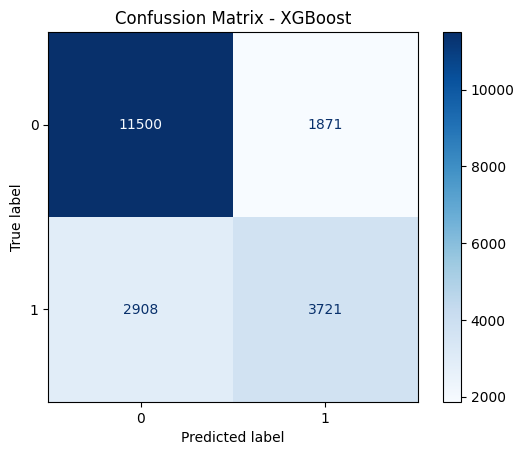

In [251]:
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    cmap="Blues"
)

plt.title("Confussion Matrix - XGBoost")
plt.show()

### PERBANDINGAN MODEL

simpan hasil evaluasi setiap model

Logistic Regression

In [252]:
lr_result = {
    "Model" : "Logistic Regression",
    "Accuracy" : accuracy_score(y_test, y_pred),
    "Precision" : precision_score(y_test, y_pred),
    "Recall" : recall_score(y_test, y_pred),
    "F1 Score" : f1_score(y_test, y_pred),
    "ROC AUC" : roc_auc_score(y_test, y_pred)

}

Decision Tree

In [253]:
dt_result = {
    "Model" : "Decision Tree",
    "Accuracy" : accuracy_score(y_test, y_pred_dt),
    "Precision" : precision_score(y_test, y_pred_dt),
    "Recall" : recall_score(y_test, y_pred_dt),
    "F1 Score" : f1_score(y_test, y_pred_dt),
    "ROC AUC" : roc_auc_score(y_test, y_pred_dt)

}

In [254]:
rf_result = {
    "Model" : "Random Forest",
    "Accuracy" : accuracy_score(y_test, y_pred_rf),
    "Precision" : precision_score(y_test, y_pred_rf),
    "Recall" : recall_score(y_test, y_pred_rf),
    "F1 Score" : f1_score(y_test, y_pred_rf),
    "ROC AUC" : roc_auc_score(y_test, y_pred_rf)

}

In [255]:
xgb_result = {
    "Model" : "XGBoost",
    "Accuracy" : accuracy_score(y_test, y_pred_xgb),
    "Precision" : precision_score(y_test, y_pred_xgb),
    "Recall" : recall_score(y_test, y_pred_xgb),
    "F1 Score" : f1_score(y_test, y_pred_xgb),
    "ROC AUC" : roc_auc_score(y_test, y_pred_xgb)

}

buat data frame


In [256]:
import pandas as pd

In [257]:
comparison = pd.DataFrame([
    lr_result,
    dt_result,
    rf_result,
    xgb_result
])

tampilkan label

In [258]:
comparison


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.75280,0.671554,0.497511,0.571577,0.688438
1,Decision Tree,0.67925,0.516018,0.519988,0.517995,0.639098
2,Random Forest,0.72925,0.611254,0.503092,0.551924,0.672233
3,XGBoost,0.76105,0.665415,0.561321,0.608952,0.710696


In [259]:
comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.7528,0.6716,0.4975,0.5716,0.6884
1,Decision Tree,0.6792,0.5160,0.5200,0.5180,0.6391
2,Random Forest,0.7292,0.6113,0.5031,0.5519,0.6722
3,XGBoost,0.7610,0.6654,0.5613,0.6090,0.7107


### HYPERPARAMETER TUNING

In [260]:
from sklearn.model_selection import RandomizedSearchCV

buat parameter

In [261]:
param_dist = {
    "model__n_estimators" : [100, 200, 300],
    "model__max_depth" : [5, 10, 15, None],
    "model__min_samples_split" : [2, 5, 10],
    "model__min_samples_leaf" : [1, 2, 4]
    

}

randomized search

In [262]:
random_search = RandomizedSearchCV(
    estimator = rf_pipeline,
    param_distributions = param_dist,
    n_iter = 20,
    cv = 5,
    scoring = "roc_auc",
    random_state = 42,
    n_jobs = -1
)

training

In [263]:
random_search.fit(x_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [5, 10, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategie

lihat parameter terbaik

In [264]:
print(random_search.best_params_)

{'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': 10}


evaluasi model terbaik

In [265]:
best_rf = random_search.best_estimator_

y_pred_best = best_rf.predict(x_test)
y_prob_best = best_rf.predict_proba(x_test)[:,1]

In [266]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.80      0.86      0.83     13371
           1       0.67      0.56      0.61      6629

    accuracy                           0.76     20000
   macro avg       0.73      0.71      0.72     20000
weighted avg       0.76      0.76      0.76     20000



In [267]:
print("Accuracy :", accuracy_score(y_test, y_pred_best))

print("Precision :", precision_score(y_test, y_pred_best))

print("Recall :", recall_score(y_test, y_pred_best))

print("F1 Score :", f1_score(y_test, y_pred_best))

print("ROC AUC :", roc_auc_score(y_test, y_prob_best))


Accuracy : 0.76195
Precision : 0.6672636103151862
Recall : 0.5620757278624227
F1 Score : 0.6101694915254238
ROC AUC : 0.8067020893762119


### FEATURE IMPORTANCE

In [268]:
import pandas as pd
import matplotlib.pyplot as plt

In [269]:
### ambil model random forest terbaik

best_model = random_search.best_estimator_.named_steps["model"]

### ambil nama fitur setelah preprocessing

feature_names = random_search.best_estimator_.named_steps["preprocessor"].get_feature_names_out()

### Feature Importance

importance = pd.DataFrame({
    "Feature" : feature_names,
    "Importance" : best_model.feature_importances_
})

importance = importance.sort_values("Importance", ascending=False)

importance.head(10)

,Feature,Importance
18,num__tenure,0.235006
19,num__monthly_charges,0.229878
2,cat__contract_One year,0.146427
3,cat__contract_Two year,0.120911
20,num__total_charges,0.102455
16,cat__charge_group_Very High,0.068293
17,num__age,0.017068
14,cat__charge_group_Low,0.016874
15,cat__charge_group_Medium,0.014983
12,cat__tenure_group_25-48,0.009886


visualisasikan top 10 feature

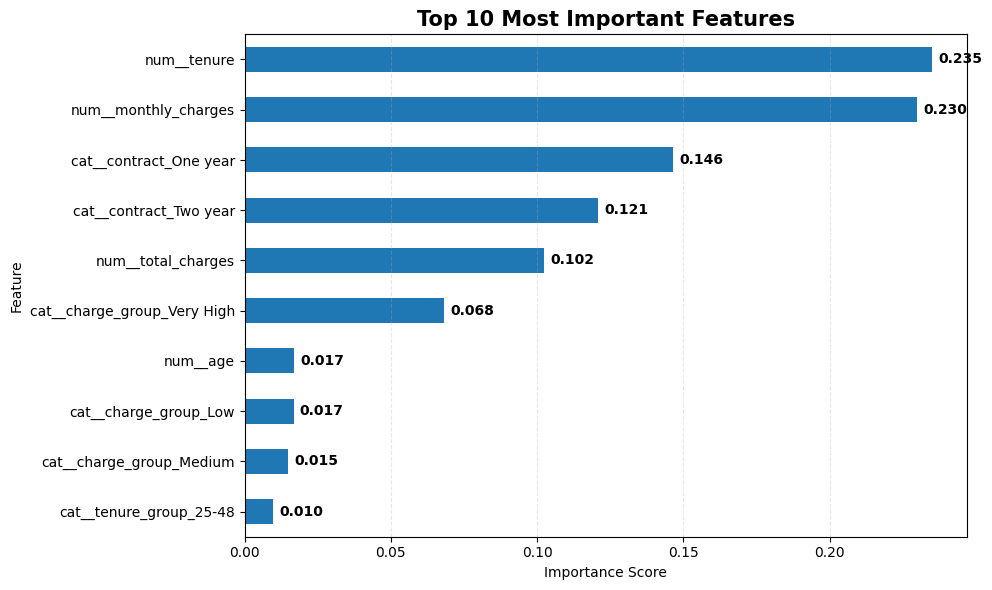

In [270]:
### Ambil Top 10

top10 = importance.head(10).sort_values("Importance")

## Plot

ax = top10.plot(
    x = "Feature",
    y = "Importance",
    kind = "barh",
    figsize=(10, 6),
    legend=False
)

## Tambahkan angka di ujung setiap bar

for i, value in enumerate(top10["Importance"]):
    ax.text(
        value + 0.002,
        i,
        f"{value:.3f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )
    
plt.title("Top 10 Most Important Features", fontsize=15, fontweight="bold")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### MODEL COMPARISON

In [271]:
import pandas as pd

simpan ke variabel berikut

In [272]:
### Logistic Regression
lr_accuracy = accuracy_score(y_test, y_pred)
lr_precision = precision_score(y_test, y_pred)
lr_recall = recall_score(y_test, y_pred)
lr_f1 = f1_score(y_test, y_pred)

### Decision Tree
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

### Random Forest
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

### XGBoost
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

In [273]:
comparison_last = pd.DataFrame({
    "Model" : [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy" : [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision" : [
        lr_precision,
        dt_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall" : [
        lr_recall,
        dt_recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score" : [
        lr_f1,
        dt_f1,
        rf_f1,
        xgb_f1
    ]
    
    
})

comparison_last

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.75280,0.671554,0.497511,0.571577
1,Decision Tree,0.67925,0.516018,0.519988,0.517995
2,Random Forest,0.72925,0.611254,0.503092,0.551924
3,XGBoost,0.76105,0.665415,0.561321,0.608952


urutkan berdasarkan f1 Score

In [274]:
comparison_sorted = comparison.sort_values(by="F1 Score", ascending=False)

comparison_sorted

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
3,XGBoost,0.76105,0.665415,0.561321,0.608952,0.710696
0,Logistic Regression,0.75280,0.671554,0.497511,0.571577,0.688438
2,Random Forest,0.72925,0.611254,0.503092,0.551924,0.672233
1,Decision Tree,0.67925,0.516018,0.519988,0.517995,0.639098


visualisasikan

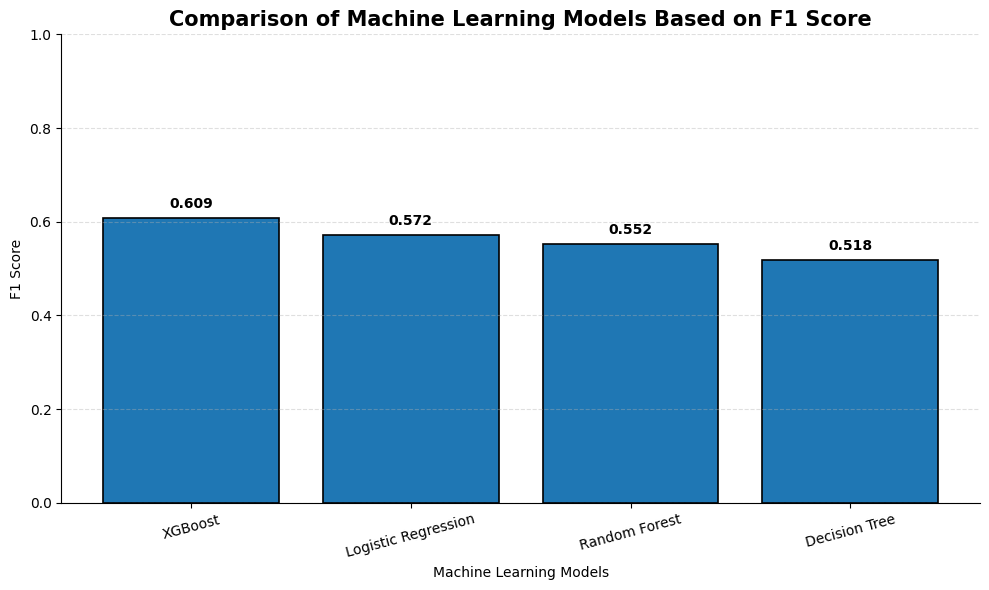

In [275]:
import matplotlib.pyplot as plt

# Membuat figure
fig, ax = plt.subplots()

# Atur ukuran figure
fig.set_size_inches(10, 6)

# Plot
bars = ax.bar(
    comparison_sorted["Model"],
    comparison_sorted["F1 Score"],
    edgecolor="black",
    linewidth=1.2
)

# Tambahkan nilai di atas bar
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{height:.3f}",
        xy=(bar.get_x() + bar.get_width()/2, height),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Judul dan label
ax.set_title(
    "Comparison of Machine Learning Models Based on F1 Score",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("Machine Learning Models")
ax.set_ylabel("F1 Score")

# Grid
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Hilangkan border atas dan kanan
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Batasi sumbu Y
ax.set_ylim(0, 1)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
